In [1]:
import sys
import importlib
from pathlib import Path

import numpy as np
import pandas as pd

cwd = Path.cwd().resolve()
repo_root = next((c for c in [cwd, *cwd.parents] if (c / "utilities" / "functions.py").exists()), None)
if repo_root is None:
    raise FileNotFoundError("Could not find the repository root containing utilities/functions.py")
sys.path.append(str(repo_root))

import utilities.functions as functions

importlib.reload(functions)

data_root = repo_root / "ms0_5"
PROTEIN, MIN_POS, MAX_POS = 'RT', 39, 226

ALL_SEQ = functions.read_seq(str(data_root / "RT" / "data" / "rt.reduce4.seq"))
with open(str(data_root / "RT" / "data" / "rt.consensus.reduce4.seq")) as f:
    CONSENSUS = f.read().strip()
REDUX = functions.get_redu_dict(str(data_root / "RT" / "data" / "rt.reduce4.redux"), 0)


def build_J_matrix(j_file, min_position, max_position):
    """Dense coupling tensor, shape (L, L, 4, 5), indexed [p1, p2, aa_at_p1, aa_at_p2]."""
    J = np.load(j_file).astype(np.float32)
    L = max_position - min_position + 1
    Jm = np.zeros((L, L, 4, 5), dtype=np.float32)
    iu0, iu1 = np.triu_indices(L, 1)
    blocks = J.reshape(-1, 4, 4)
    assert blocks.shape[0] == iu0.size, "J.npy row count does not match the position range"
    Jm[iu0, iu1, :, :4] = blocks
    Jm[iu1, iu0, :, :4] = blocks.transpose(0, 2, 1)
    return Jm


J = build_J_matrix(str(data_root / "RT" / "data" / "J_RT.npy"), MIN_POS, MAX_POS)
L = MAX_POS - MIN_POS + 1
print(f"{PROTEIN}: {len(ALL_SEQ):,} sequences, {L} positions")

RT: 19,194 sequences, 188 positions


In [2]:
# ---------------------------------------------------------------------------
# Where the range of dE double comes from, term by term.
#
# For a pair (p1: wt1->mt1, p2: wt2->mt2), dE double splits EXACTLY into one term per
# background position q, plus the direct p1-p2 coupling:
#
#     dE double = sum_{q not in {p1,p2}} c(q)  +  [J(p1,p2,wt1,wt2) - J(p1,p2,mt1,mt2)]
#     c(q)      = [J(p1,q,wt1,s_q) - J(p1,q,mt1,s_q)] + [J(p2,q,wt2,s_q) - J(p2,q,mt2,s_q)]
#
# Every term is a DIFFERENCE of J values, and the only thing that changes from sequence to
# sequence is s_q, the residue the background happens to carry at q. So each position q can
# take just four values -- one per residue A/B/C/D -- and how much q moves dE double depends
# on two things:
#
#     lever   how far apart those four values are (a property of J alone)
#     usage   how often the alignment actually visits the residues that differ
#
# A position with a big lever that is never mutated contributes nothing to the range; a
# position that varies a lot but whose four J differences are equal contributes nothing
# either. Both have to be non-trivial, which is what CVAL and FREQ below separate.
# ---------------------------------------------------------------------------
_AA_CODE = np.full(256, 4, dtype=np.uint8)
for _i, _c in enumerate("ABCD"):
    _AA_CODE[ord(_c)] = _i


def encode_seqs(seq_list, min_pos, max_pos):
    Ln = max_pos - min_pos + 1
    N = len(seq_list)
    raw = np.frombuffer("".join(seq_list).encode(), dtype=np.uint8)
    assert raw.size == N * Ln, "all sequences must span exactly min_pos..max_pos"
    codes = _AA_CODE[raw.reshape(N, Ln)]
    onehot = np.zeros((N * Ln, 5), dtype=np.float32)
    onehot[np.arange(N * Ln), codes.ravel()] = 1.0
    return codes, onehot.reshape(N, Ln * 5)


def _site_energies(onehot, Jm, p, excluded):
    A = Jm[p].copy()
    A[list(excluded)] = 0.0
    return np.asarray(onehot @ A.transpose(0, 2, 1).reshape(-1, 4), dtype=np.float64)


def reduced_idx(pair):
    """'M41L-T215Y' -> (p1, p2, wt1, mt1, wt2, mt2) as 0-based position / residue indices."""
    a, b = functions.split_pairs(pair)
    wt1, pos1, mt1 = functions.split_pair(functions.unreduced_to_reduced(REDUX, a))
    wt2, pos2, mt2 = functions.split_pair(functions.unreduced_to_reduced(REDUX, b))
    return (pos1 - MIN_POS, pos2 - MIN_POS, "ABCD".index(wt1), "ABCD".index(mt1),
            "ABCD".index(wt2), "ABCD".index(mt2))


def decompose(pair, codes, onehot):
    """Per-position J-difference terms for one pair.

    Returns
        C      (N, L)  c(q) for every sequence and position -- the realized terms
        CVAL   (L, 4)  the four values c(q) can take, one per residue at q  (J only)
        de     (N,)    dE double, rebuilt from the terms and checked against the direct route
        direct scalar  the p1-p2 coupling difference, the one term with no background in it
    """
    p1, p2, wt1, mt1, wt2, mt2 = reduced_idx(pair)
    qs = np.arange(L)

    CVAL = ((J[p1][qs[:, None], wt1, np.arange(4)[None, :]]
             - J[p1][qs[:, None], mt1, np.arange(4)[None, :]])
            + (J[p2][qs[:, None], wt2, np.arange(4)[None, :]]
               - J[p2][qs[:, None], mt2, np.arange(4)[None, :]])).astype(np.float64)
    CVAL[[p1, p2]] = 0.0                      # the pair's own positions carry no background term

    C = CVAL[qs[None, :], codes]              # (N, L) realized terms
    direct = float(J[p1, p2, wt1, wt2] - J[p1, p2, mt1, mt2])

    S1 = _site_energies(onehot, J, p1, (p1, p2))
    S2 = _site_energies(onehot, J, p2, (p1, p2))
    J12 = J[p1, p2, :, :4].astype(np.float64)
    M = S1[:, :, None] + S2[:, None, :] + J12[None, :, :]
    de = M[:, wt1, wt2] - M[:, mt1, mt2]
    assert np.allclose(C.sum(axis=1) + direct, de, atol=1e-3), pair
    return C, CVAL, de, direct


print("machinery ready")

machinery ready


In [3]:
# =============================================================================
# The pairs to compare: the widest dE double ranges in RT against the narrowest, which is the
# 122/123 pair. Ranges are recomputed here (95th - 5th percentile) so the notebook does not
# depend on the earlier CSV.
# =============================================================================
TOP = ['L210W-T215Y', 'M41L-L210W', 'M41L-T215Y']
BOTTOM = ['K122E-D123N', 'V118I-F214L', 'Y181C-G190A']
GROUP = {**{p: 'widest range' for p in TOP}, **{p: 'narrowest range' for p in BOTTOM}}

CODES, ONEHOT = encode_seqs(ALL_SEQ, MIN_POS, MAX_POS)
_cons_codes, _ = encode_seqs([CONSENSUS], MIN_POS, MAX_POS)
U = _cons_codes[0]
FREQ = np.stack([(CODES == a).mean(axis=0) for a in range(4)], axis=1)   # (L, 4) residue usage

TERMS = {}
rows = []
for pair in TOP + BOTTOM:
    C, CVAL, de, direct = decompose(pair, CODES, ONEHOT)

    sd_q = C.std(axis=0)                       # how much each position moves dE double
    lever_q = CVAL.max(axis=1) - CVAL.min(axis=1)   # spread of the four J differences at q
    lo, hi = np.percentile(de, [5, 95])
    TERMS[pair] = dict(C=C, CVAL=CVAL, sd_q=sd_q, lever_q=lever_q, de=de, direct=direct)

    order = np.argsort(-sd_q)
    rows.append({
        'pair': pair, 'group': GROUP[pair],
        'dE double range': hi - lo,
        'sd(dE double)': de.std(),
        'positions with sd > 0.25': int((sd_q > 0.25).sum()),
        'largest position sd': sd_q.max(),
        'top-5 positions': ', '.join(str(q + MIN_POS) for q in order[:5]),
        'sum of term variances': (C.var(axis=0)).sum(),
        'total variance': de.var(),
    })

SUMMARY = pd.DataFrame(rows)
SUMMARY['covariance share %'] = (100 * (1 - SUMMARY['sum of term variances']
                                        / SUMMARY['total variance'])).round(1)
SUMMARY.round(2)

,pair,group,dE double range,sd(dE double),positions with sd > 0.25,largest position sd,top-5 positions,sum of term variances,total variance,covariance share %
0,L210W-T215Y,widest range,19.80,6.29,17,2.45,"41, 214, 118, 44, 67",11.78,39.58,70.2
1,M41L-L210W,widest range,18.74,6.00,14,2.82,"215, 214, 44, 43, 118",12.45,36.06,65.5
2,M41L-T215Y,widest range,17.86,5.68,16,1.89,"210, 44, 214, 43, 67",8.75,32.23,72.8
3,K122E-D123N,narrowest range,3.37,1.04,1,0.26,"135, 121, 48, 118, 83",0.60,1.07,43.8
4,V118I-F214L,narrowest range,5.04,1.54,7,0.48,"135, 162, 215, 83, 219",1.79,2.38,24.7
5,Y181C-G190A,narrowest range,7.39,2.24,11,1.03,"101, 100, 74, 221, 215",3.38,5.03,32.8


saved jterm_distribution.png


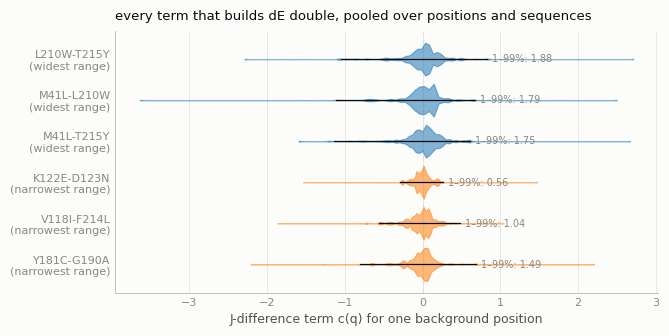

In [4]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

SURFACE, INK, INK2, MUTED, GRID, BASE = '#fcfcfb', '#0b0b0b', '#52514e', '#898781', '#e6e5df', '#c3c2b7'
WIDE, NARROW = '#1f77b4', '#ff7f0e'
GROUP_COLOR = {'widest range': WIDE, 'narrowest range': NARROW}

plt.rcParams.update({'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
                     'savefig.facecolor': SURFACE, 'font.size': 9, 'legend.frameon': False,
                     'axes.edgecolor': BASE, 'axes.linewidth': 0.7})


def bare(ax, grid='both'):
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
    for s in ('left', 'bottom'):
        ax.spines[s].set_color(BASE)
    ax.tick_params(length=0, labelsize=8, colors=MUTED)
    ax.grid(axis=grid if grid != 'both' else 'both', color=GRID, linewidth=0.6)
    ax.set_axisbelow(True)
    return ax


# =============================================================================
# FIGURE 1 -- the distribution of the J-difference terms themselves.
#
# One row per pair: every realized term c(q), pooled over all positions and all sequences.
# A pair with a wide dE double range is a pair whose terms have wide tails -- there are
# positions in the background that swing it by a unit or more, in both directions. For the
# narrow-range pairs the whole distribution collapses towards zero: no single background
# position has any leverage on them, so nothing the rest of the sequence does matters much.
# =============================================================================
fig, ax = plt.subplots(figsize=(7.0, 3.4))
order = TOP + BOTTOM
for i, pair in enumerate(order[::-1]):
    C = TERMS[pair]['C']
    vals = C[:, C.std(axis=0) > 0].ravel()          # positions that vary at all
    parts = ax.violinplot([vals], positions=[i], vert=False, widths=0.8,
                          showextrema=False, showmedians=False)
    for body in parts['bodies']:
        body.set_facecolor(GROUP_COLOR[GROUP[pair]])
        body.set_alpha(0.55)
        body.set_edgecolor(GROUP_COLOR[GROUP[pair]])
        body.set_linewidth(0.8)
    q1, q99 = np.percentile(vals, [1, 99])
    ax.plot([q1, q99], [i, i], color=INK, lw=0.9, zorder=4)
    ax.text(q99 + 0.06, i, f'1–99%: {q99 - q1:.2f}', va='center', fontsize=7, color=MUTED)

ax.axvline(0, color=BASE, ls=(0, (4, 3)), lw=0.8, zorder=0)
ax.set_yticks(range(len(order)), [f'{p}\n({GROUP[p]})' for p in order[::-1]], fontsize=8,
              color=INK2)
ax.set_xlabel('J-difference term c(q) for one background position', color=INK2)
ax.set_title('every term that builds dE double, pooled over positions and sequences',
             fontsize=9.5, color=INK, loc='left', pad=8)
bare(ax, grid='x')
fig.savefig('jterm_distribution.png', dpi=400, bbox_inches='tight', pad_inches=0.02,
            facecolor=SURFACE)
print('saved jterm_distribution.png')
plt.show()


saved jterm_distribution_two_pairs.png


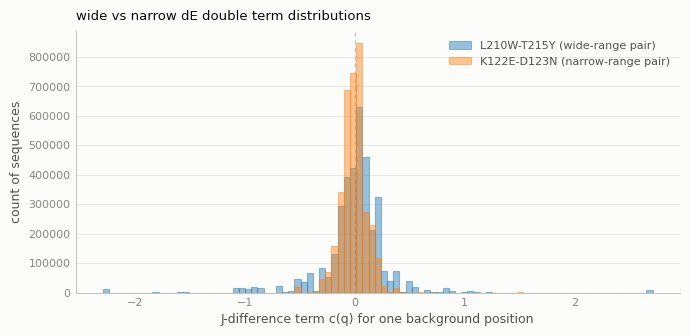

In [10]:
# =============================================================================
# FIGURE 4 -- both pairs on one histogram, with actual sequence counts on y-axis.
# =============================================================================
PAIR_ORDER = ['L210W-T215Y', 'K122E-D123N']
PAIR_KIND = {'L210W-T215Y': 'wide-range pair', 'K122E-D123N': 'narrow-range pair'}
PAIR_COLOR = {'wide-range pair': WIDE, 'narrow-range pair': NARROW}

vals_by_pair = {}
all_vals = []
for pair in PAIR_ORDER:
    C = TERMS[pair]['C']
    vals = C[:, C.std(axis=0) > 0].ravel()
    vals_by_pair[pair] = vals
    all_vals.append(vals)

all_vals = np.concatenate(all_vals)
bins = np.linspace(all_vals.min(), all_vals.max(), 90)

fig, ax = plt.subplots(figsize=(7.8, 3.4))

for pair in PAIR_ORDER:
    vals = vals_by_pair[pair]
    color = PAIR_COLOR[PAIR_KIND[pair]]
    ax.hist(vals, bins=bins, alpha=0.45, color=color, edgecolor=color, linewidth=0.8,
            label=f'{pair} ({PAIR_KIND[pair]})')

ax.axvline(0, color=BASE, ls=(0, (4, 3)), lw=0.8, zorder=0)
ax.set_xlabel('J-difference term c(q) for one background position', color=INK2)
ax.set_ylabel('count of sequences', color=INK2)
ax.set_title('wide vs narrow dE double term distributions', fontsize=9.5, color=INK, loc='left', pad=8)
bare(ax, grid='y')
ax.legend(fontsize=8, labelcolor=INK2)

fig.savefig('jterm_distribution_two_pairs.png', dpi=400, bbox_inches='tight', pad_inches=0.02,
            facecolor=SURFACE)
print('saved jterm_distribution_two_pairs.png')
plt.show()


saved jterm_leverage_by_position.png


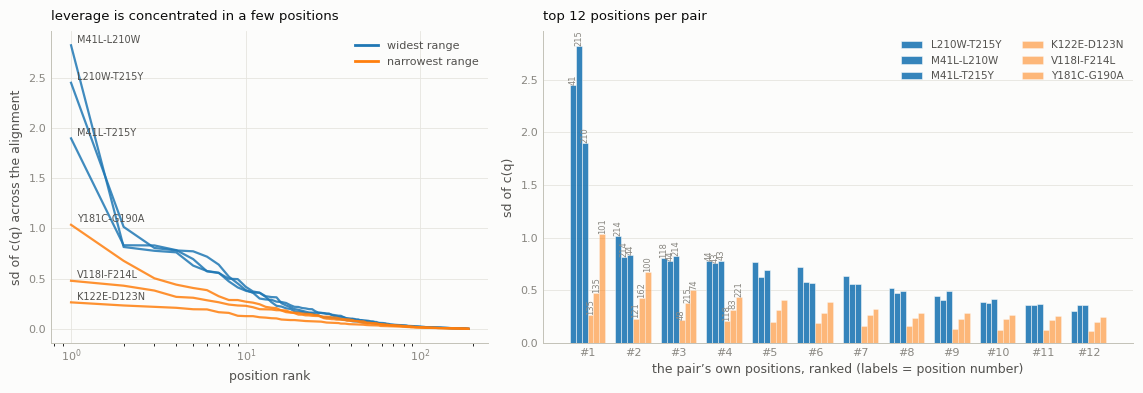

In [6]:
# =============================================================================
# FIGURE 2 -- which positions carry it, and why.
#
# Left: for each pair, the per-position sd of c(q), sorted, over all 188 positions. A
# wide-range pair has a handful of positions with real leverage and a long flat tail; the
# narrow-range pairs are flat from the start -- there is no position to point at.
#
# Right: the same information as the top 12 named positions per pair, so the leverage can be
# read off as sequence positions rather than as a curve.
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0),
                         gridspec_kw={'width_ratios': [1, 1.35]})

ax = axes[0]
for pair in TOP + BOTTOM:
    sd = np.sort(TERMS[pair]['sd_q'])[::-1]
    ax.plot(np.arange(1, len(sd) + 1), sd, color=GROUP_COLOR[GROUP[pair]],
            lw=1.6 if GROUP[pair] == 'widest range' else 1.6, alpha=0.85)
    ax.annotate(pair, (1, sd[0]), textcoords='offset points', xytext=(4, 2), fontsize=7,
                color=INK2)
ax.set_xscale('log')
ax.set_xlabel('position rank', color=INK2)
ax.set_ylabel('sd of c(q) across the alignment', color=INK2)
ax.set_title('leverage is concentrated in a few positions', fontsize=9.5, color=INK,
             loc='left', pad=8)
bare(ax)
ax.legend(handles=[Line2D([], [], color=c, lw=2, label=g) for g, c in GROUP_COLOR.items()],
          loc='upper right', fontsize=8, labelcolor=INK2)

ax = axes[1]
TOPN = 12
width = 0.13
for k, pair in enumerate(TOP + BOTTOM):
    sd = TERMS[pair]['sd_q']
    o = np.argsort(-sd)[:TOPN]
    ax.bar(np.arange(TOPN) + (k - 2.5) * width, sd[o], width=width,
           color=GROUP_COLOR[GROUP[pair]], alpha=0.55 if GROUP[pair] == 'narrowest range' else 0.9,
           edgecolor=SURFACE, linewidth=0.4, label=pair)
    for j, q in enumerate(o[:4]):
        ax.text(j + (k - 2.5) * width, sd[q] + 0.02, str(q + MIN_POS), ha='center',
                fontsize=6, color=MUTED, rotation=90)
ax.set_xticks(range(TOPN), [f'#{i+1}' for i in range(TOPN)], fontsize=8)
ax.set_xlabel('the pair’s own positions, ranked (labels = position number)', color=INK2)
ax.set_ylabel('sd of c(q)', color=INK2)
ax.set_title('top 12 positions per pair', fontsize=9.5, color=INK, loc='left', pad=8)
bare(ax, grid='y')
ax.legend(fontsize=7.5, labelcolor=INK2, ncol=2)

fig.tight_layout()
fig.savefig('jterm_leverage_by_position.png', dpi=400, bbox_inches='tight', pad_inches=0.02,
            facecolor=SURFACE)
print('saved jterm_leverage_by_position.png')
plt.show()

saved jterm_four_values.png


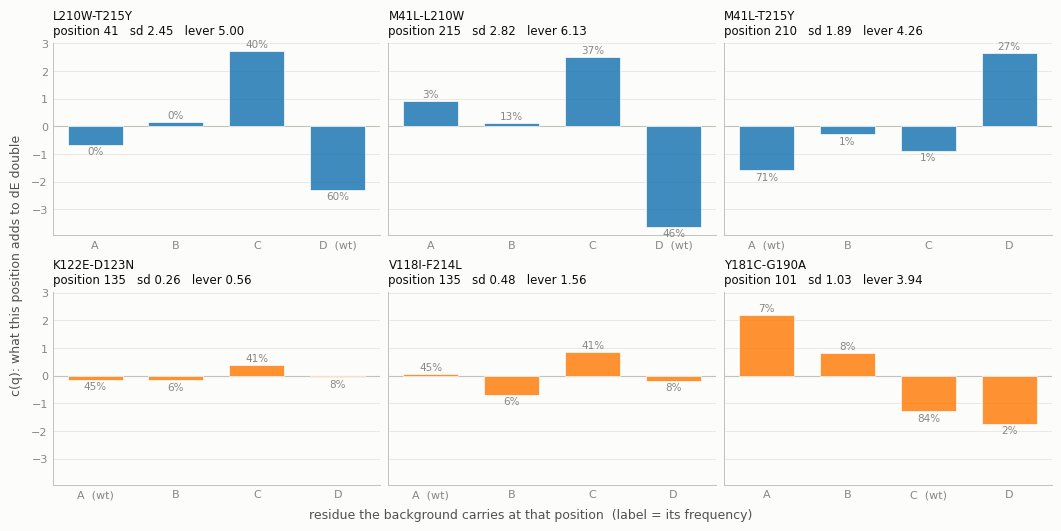

In [7]:
# =============================================================================
# FIGURE 3 -- "if it is A, B, C or D": the four values a single position can take.
#
# For the strongest position of each pair, the four bars are the four values c(q) takes, one
# per residue the background could carry there, and the number above each bar is how often
# the alignment actually carries it. This is the whole mechanism in one panel:
#
#   a wide-range pair needs a position where the four values are far apart AND where the
#   alignment really visits more than one of them
#
# For the narrow-range pairs the four bars are nearly the same height, so it makes no
# difference which residue the background has -- and that is why dE double barely moves.
# =============================================================================
fig, axes = plt.subplots(2, 3, figsize=(10.5, 5.2), sharey=True, layout='constrained')
for ax, pair in zip(axes.ravel(), TOP + BOTTOM):
    d = TERMS[pair]
    q = int(np.argmax(d['sd_q']))
    vals = d['CVAL'][q]
    freq = FREQ[q]
    colour = GROUP_COLOR[GROUP[pair]]
    ax.bar(range(4), vals, width=0.68, color=colour, alpha=0.85, edgecolor=SURFACE,
           linewidth=0.6, zorder=3)
    for a in range(4):
        ax.text(a, vals[a] + (0.06 if vals[a] >= 0 else -0.06),
                f'{100 * freq[a]:.0f}%', ha='center',
                va='bottom' if vals[a] >= 0 else 'top', fontsize=7.5, color=MUTED)
    ax.axhline(0, color=BASE, lw=0.8)
    ax.set_xticks(range(4), [f'{c}{"  (wt)" if a == U[q] else ""}'
                             for a, c in enumerate("ABCD")], fontsize=8)
    ax.set_title(f'{pair}\nposition {q + MIN_POS}   sd {d["sd_q"][q]:.2f}   '
                 f'lever {d["lever_q"][q]:.2f}', fontsize=8.5, color=INK, loc='left')
    bare(ax, grid='y')

fig.supylabel('c(q): what this position adds to dE double', fontsize=9, color=INK2)
fig.supxlabel('residue the background carries at that position  (label = its frequency)',
              fontsize=9, color=INK2)
fig.savefig('jterm_four_values.png', dpi=400, bbox_inches='tight', pad_inches=0.02,
            facecolor=SURFACE)
print('saved jterm_four_values.png')
plt.show()